In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
labels = ["[AF] African American", "[AF] North African", "[AF] Sub-Saharan", "[AF] Others",
          
          "[AS] East Asian", "[AS] Middle-East/West Asian", "[AS] South Asian", "[AS] South-East Asian", "[AS] Others", 
          
          "[EU] European",
          "[O] Latin/Hispanic", "[O] Native American", "[O] Others"
         ]

66.89769230769231
81.23846153846154
49.64923076923076
67.94615384615385


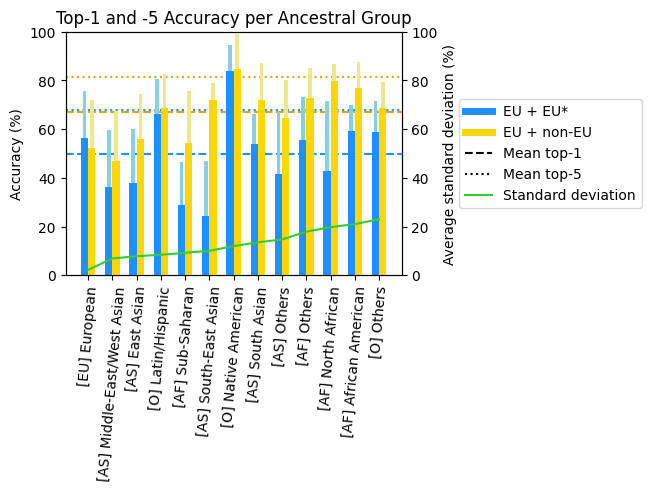

In [3]:
# Data averaged over 5 runs using random sampling - GMDB v1.1.0

labels = np.array(
    [
        "[AF] African American", "[AF] North African", "[AF] Sub-Saharan", "[AF] Others",
        "[AS] East Asian", "[AS] Middle-East/West Asian", "[AS] South Asian", "[AS] South-East Asian", "[AS] Others", 
        "[EU] European",
        "[O] Latin/Hispanic", "[O] Native American", "[O] Others"
    ])

# These results were retrieved with evaluate_ancestry_classification.py, which 
# needs the performance and results files in the `./experiments_anc`-directory,
# which can be found in our supplied material

# python evaluate_ancestry_classification.py --set others
all_avg_t1 = np.array([
    77.08, 79.64, 54.23, 72.78, 
    55.78, 46.76, 72.15, 72.12, 64.66,
    52.35, 
    68.86, 84.55, 68.71
])

all_avg_t5 = np.array([
    87.50, 86.64, 75.49, 85.00,
    74.56, 67.59, 87.32, 78.81, 80.06,
    72.05,
    82.56, 99.09, 79.43
])

# python evaluate_ancestry_classification.py --set eu
eu_avg_t1 = np.array([
    59.38, 42.71, 28.91, 55.56,
    37.77, 36.10, 53.70, 24.40, 41.64,
    56.17,
    66.16, 83.94, 59.00
])

eu_avg_t5 = np.array([
    69.79, 71.64, 46.55, 73.33,
    60.13, 59.67, 66.13, 46.83, 66.84,
    75.66,
    80.51, 94.65, 71.57
])

## Sort labels by top-1 accuracy
sorted_labels = ['[O] Others', '[AF] African American', '[AF] North African', '[AF] Others', '[AS] Others', '[AS] South Asian', '[O] Native American', '[AS] South-East Asian', '[AF] Sub-Saharan', '[O] Latin/Hispanic', '[AS] East Asian', '[AS] Middle-East/West Asian', '[EU] European'][::-1] # performance std top-1 (high->low)
sort_title = "acc std top-1"

# Righthand y-axis explaining sorting of ancestries
second_y = [23.01, 21.02, 19.77, 17.93, 14.72, 13.55, 11.98, 10.06, 9.25, 8.41, 7.85, 6.91, 2.29][::-1] # acc std top1

# Actually sort
sort_idx = [np.where(labels == i)[0][0] for i in sorted_labels]
labels = labels[sort_idx]
all_avg_t1 = all_avg_t1[sort_idx]
all_avg_t5 = all_avg_t5[sort_idx]
eu_avg_t1 = eu_avg_t1[sort_idx]
eu_avg_t5 = eu_avg_t5[sort_idx]
## End: Sorting

fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(labels))
width = 0.3

offset = 0.15
rects = ax.bar(x + offset, eu_avg_t5, width/2, label="Top-5", color="skyblue", zorder=3)
rects = ax.bar(x + offset, eu_avg_t1, width, label="Top-1", color="dodgerblue", zorder=3)

offset = width + 0.15
rects = ax.bar(x + offset, all_avg_t5, width/2, label="Top-5", color="khaki",zorder=3)
rects = ax.bar(x + offset, all_avg_t1, width, label="Top-1", color="gold", zorder=3)

ax.set_title(f"Top-1 and -5 Accuracy per Ancestral Group")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x+width, labels, rotation=85)
ax.set_ylim(0, 100)

from matplotlib.lines import Line2D

## Custom legend
custom_lines = [Line2D([0], [0], color="dodgerblue", lw=5, label='EU + EU*'),
                Line2D([0], [0], color="gold", lw=5, label='EU + non-EU')]

extra_lines = [plt.Line2D([], [], linestyle='--', label='Mean top-1', color='black'),
               plt.Line2D([], [], linestyle=':', label='Mean top-5', color='black'),
               plt.Line2D([], [], linestyle='-', label='Standard deviation', color='limegreen')]
ax.legend(handles=custom_lines + extra_lines, loc='center left', bbox_to_anchor=(1.15, 0.5))
## End: Legend

plt.axhline(y=np.mean(all_avg_t1), color='goldenrod', ls='--', zorder=2)
plt.axhline(y=np.mean(all_avg_t5), color='goldenrod', ls=':', zorder=2)
print(np.mean(all_avg_t1))
print(np.mean(all_avg_t5))

plt.axhline(y=np.mean(eu_avg_t1), color='dodgerblue', ls='--', zorder=2)
plt.axhline(y=np.mean(eu_avg_t5), color='dodgerblue', ls=':', zorder=2)
print(np.mean(eu_avg_t1))
print(np.mean(eu_avg_t5))

# draw a vertical line at location X
# plt.axvline(x = 7.8, color = 'red')

# add second y-axis
ax2 = ax.twinx()
# ax2.plot(np.append(x, x[-1]+0.6), second_y+[second_y[-1]], color='limegreen')
ax2.plot(x+0.3, second_y, color='limegreen')
ax2.set_ylabel("Average standard deviation (%)")
ax2.set_ylim(0,100)

plt.savefig('accuracy_eth_sort.svg', dpi=300)
plt.show()

In [4]:
## Results obtained by running the gallery set expansion for 20 folds
# `python evaluate_ancestry_clustering.py --gallery_expansion --seed 42 --repeat_N 10 --stdev`
# where the `--stdev` is used for the standard deviations in the next cell

# results for each experiment .. [top_1, top_5, top_10, top_30]
# African (n=29)
# Asian (n=127)
# European (n=523)
# Others (n=69)
# Unknown (n=134)

# EU Only:
African0= [0.37931034, 0.44827586, 0.51724138, 0.65517241]
Asian0= [0.41732283, 0.60629921, 0.65354331, 0.77165354]
European0= [0.55640535, 0.74760994, 0.82600382, 0.90248566]
Others0= [0.60869565, 0.73913043, 0.76811594, 0.84057971]
Unknown0= [0.47014925, 0.62686567, 0.6641791 , 0.74626866]

# Others only:
African_only= [0.62068966, 0.82758621, 0.82758621, 0.93103448]
Asian_only= [0.55905512, 0.77165354, 0.83464567, 0.88976378]
European_only= [0.40726577, 0.61950287, 0.66921606, 0.78585086]
Others_only= [0.72463768, 0.7826087 , 0.82608696, 0.89855072]
Unknown_only= [0.52238806, 0.76865672, 0.82835821, 0.92537313]

# EU + 10% others:
African1= [0.5137931, 0.63103448, 0.66551724, 0.79655172]
Asian1= [0.44330709, 0.63779528, 0.72755906, 0.82677165]
European1= [0.55793499, 0.74608031, 0.82447419, 0.9040153]
Others1= [0.64057971, 0.76956522, 0.7884058, 0.87101449]
Unknown1= [0.48731343, 0.65671642, 0.70597015, 0.79701493]

# EU + 20% others:
African2= [0.55517241, 0.71034483, 0.74137931, 0.84137931]
Asian2= [0.47086614, 0.68267717, 0.76377953, 0.86220472]
European2= [0.55755258, 0.74780115, 0.82619503, 0.90516252]
Others2= [0.65652174, 0.77246377, 0.7884058, 0.88115942]
Unknown2= [0.50597015, 0.67761194, 0.73358209, 0.83432836]

# EU + 30% others:
African3= [0.59310345, 0.74137931, 0.75517241, 0.84482759]
Asian3= [0.48818898, 0.7015748, 0.77874016, 0.85905512]
European3= [0.55736138, 0.74971319, 0.82447419, 0.90592734]
Others3= [0.65942029, 0.77971014, 0.80289855, 0.89275362]
Unknown3= [0.51716418, 0.68507463, 0.75373134, 0.85895522]

# EU + 40% others:
African4= [0.59310345, 0.76896552, 0.78965517, 0.86551724]
Asian4= [0.48740157, 0.72047244, 0.7976378, 0.88110236]
European4= [0.55697897, 0.7500956, 0.82466539, 0.90439771]
Others4= [0.6942029, 0.79565217, 0.82318841, 0.9115942]
Unknown4= [0.52462687, 0.70373134, 0.77313433, 0.8738806]

# EU + 50% others:
African5= [0.63448276, 0.78965517, 0.79655172, 0.8862069]
Asian5= [0.49527559, 0.72047244, 0.79133858, 0.88188976]
European5= [0.55736138, 0.74913958, 0.8248566, 0.90478011]
Others5= [0.6942029, 0.7942029, 0.81594203, 0.91449275]
Unknown5= [0.51716418, 0.71492537, 0.78731343, 0.88358209]

# EU + 60% others:
African6= [0.58275862, 0.80344828, 0.80344828, 0.9]
Asian6= [0.51259843, 0.7488189, 0.81417323, 0.88110236]
European6= [0.55621415, 0.75162524, 0.82772467, 0.90516252]
Others6= [0.7, 0.79710145, 0.81014493, 0.9115942]
Unknown6= [0.52910448, 0.71865672, 0.78731343, 0.89253731]

# EU + 70% others:
African7= [0.62068966, 0.82068966, 0.82413793, 0.88275862]
Asian7= [0.50629921, 0.75984252, 0.81968504, 0.89055118]
European7= [0.55717017, 0.7500956, 0.82695985, 0.9042065]
Others7= [0.72173913, 0.8, 0.81304348, 0.92028986]
Unknown7= [0.53208955, 0.72238806, 0.80074627, 0.89925373]

# EU + 80% others:
African8= [0.63448276, 0.81724138, 0.81724138, 0.88275862]
Asian8= [0.52598425, 0.77322835, 0.82992126, 0.89370079]
European8= [0.55602294, 0.75028681, 0.82428298, 0.90248566]
Others8= [0.72318841, 0.80434783, 0.8057971, 0.91594203]
Unknown8= [0.5358209, 0.7238806, 0.80298507, 0.90970149]

# EU + 90% others:
African9= [0.63103448, 0.82758621, 0.82758621, 0.8862069]
Asian9= [0.52913386, 0.78031496, 0.84566929, 0.89448819]
European9= [0.5541109, 0.75315488, 0.82466539, 0.90267686]
Others9= [0.72898551, 0.80724638, 0.80869565, 0.92173913]
Unknown9= [0.53134328, 0.72462687, 0.80149254, 0.9119403]
         
# EU + 100% others (a.k.a. the entire, standard gallery:
African_all = [0.62068966, 0.82758621, 0.82758621, 0.86206897]
Asian_all = [0.53543307, 0.78740157, 0.8503937 , 0.8976378 ]
European_all = [0.55449331, 0.75143403, 0.82600382, 0.90248566]
Others_all = [0.73913043, 0.8115942 , 0.8115942 , 0.92753623]
Unknown_all = [0.53731343, 0.73134328, 0.81343284, 0.91044776]

In [5]:
# standard deviations for the 10-fold experiment 
# (code snippet to reproduce in previous cell)
African0_std = [5.55111512e-17, 1.11022302e-16, 1.11022302e-16, 1.11022302e-16]
African1_std = [8.64823186e-02, 3.79310345e-02, 4.63918071e-02, 3.91648851e-02]
African2_std = [3.91648851e-02, 5.16090674e-02, 5.17241379e-02, 4.13793103e-02]
African3_std = [8.96551724e-02, 5.17241379e-02, 4.20915711e-02, 3.53343130e-02]
African4_std = [6.68645498e-02, 4.37537157e-02, 3.60010569e-02, 3.91648851e-02]
African5_std = [4.67746895e-02, 2.86435306e-02, 3.25309694e-02, 3.46547435e-02]
African6_std = [4.98511458e-02, 2.69318954e-02, 2.69318954e-02, 2.86435306e-02]
African7_std = [4.08005502e-02, 1.37931034e-02, 1.03448276e-02, 2.28732744e-02]
African8_std = [3.83983749e-02, 2.20797387e-02, 2.20797387e-02, 2.28732744e-02]
African9_std = [3.10344828e-02, 1.11022302e-16, 1.11022302e-16, 1.58019852e-02]
African_all_std = [0.00000000e+00, 1.11022302e-16, 1.11022302e-16, 0.00000000e+00]

Asian0_std = [5.55111512e-17, 1.11022302e-16, 1.11022302e-16, 1.11022302e-16]
Asian1_std = [1.49606299e-02, 1.45189676e-02, 1.76771215e-02, 1.65166748e-02]
Asian2_std = [1.60599040e-02, 1.61561296e-02, 2.05329210e-02, 1.90447033e-02]
Asian3_std = [1.96061411e-02, 3.27411384e-02, 2.09661842e-02, 1.13833325e-02]
Asian4_std = [2.37398637e-02, 2.06082714e-02, 1.79727751e-02, 1.13833325e-02]
Asian5_std = [1.84494087e-02, 1.93675179e-02, 1.87163218e-02, 1.05641007e-02]
Asian6_std = [1.74120822e-02, 2.00594318e-02, 1.90284189e-02, 8.22071379e-03]
Asian7_std = [2.11428686e-02, 1.80416366e-02, 1.42821710e-02, 5.51181102e-03]
Asian8_std = [8.48057450e-03, 1.64414276e-02, 1.54298566e-02, 1.07098193e-02]
Asian9_std = [9.18260141e-03, 8.94316275e-03, 5.22303117e-03, 5.22303117e-03]
Asian_all_std = [0.00000000e+00, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00]

European0_std = [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 2.22044605e-16]
European1_std = [3.99246903e-03, 3.05927342e-03, 2.22980952e-03, 2.67686424e-03]
European2_std = [2.44861348e-03, 6.07356794e-03, 3.96028971e-03, 2.73094777e-03]
European3_std = [3.22790497e-03, 5.16252390e-03, 3.80492328e-03, 2.93734063e-03]
European4_std = [6.78978237e-03, 5.27461347e-03, 5.13411915e-03, 3.72726361e-03]
European5_std = [5.93966523e-03, 5.72337650e-03, 3.74682943e-03, 1.43084412e-03]
European6_std = [3.13598843e-03, 4.05155260e-03, 3.46813712e-03, 3.10670685e-03]
European7_std = [4.20650096e-03, 5.06241006e-03, 3.65295854e-03, 2.48565966e-03]
European8_std = [3.39892712e-03, 3.33376592e-03, 4.56094090e-03, 1.48106438e-03]
European9_std = [1.87341472e-03, 2.17166667e-03, 2.57239466e-03, 1.33843212e-03]
European_all_std = [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 2.22044605e-16]

Others0_std = [0.00000000e+00, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00]
Others1_std = [1.81014435e-02, 1.64606039e-02, 1.85597804e-02, 1.36724364e-02]
Others2_std = [2.75362319e-02, 1.94980059e-02, 1.47797667e-02, 1.41999405e-02]
Others3_std = [2.07504653e-02, 1.81014435e-02, 1.73913043e-02, 1.15942029e-02]
Others4_std = [1.99242422e-02, 1.36724364e-02, 1.26344897e-02, 1.20385853e-02]
Others5_std = [2.28691795e-02, 1.69013098e-02, 1.30434783e-02, 1.20385853e-02]
Others6_std = [1.59420290e-02, 1.12260387e-02, 7.80458668e-03, 1.36724364e-02]
Others7_std = [1.69013098e-02, 1.26344897e-02, 7.80458668e-03, 9.72203468e-03]
Others8_std = [1.51308790e-02, 9.72203468e-03, 7.09997027e-03, 8.69565217e-03]
Others9_std = [9.27989020e-03, 9.27989020e-03, 5.79710145e-03, 9.61340519e-03]
Others_all_std = [1.11022302e-16, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]

Unknown0_std = [0.00000000e+00, 1.11022302e-16, 1.11022302e-16, 0.00000000e+00]
Unknown1_std = [1.63669494e-02, 1.29257523e-02, 1.21254305e-02, 1.44706861e-02]
Unknown2_std = [1.66201921e-02, 2.35518415e-02, 1.49440182e-02, 1.91138037e-02]
Unknown3_std = [1.94746095e-02, 1.94029851e-02, 1.15611443e-02, 1.35360874e-02]
Unknown4_std = [1.60230676e-02, 1.56716418e-02, 1.34328358e-02, 1.07886808e-02]
Unknown5_std = [8.86144932e-03, 1.48505588e-02, 8.98626461e-03, 1.06588484e-02]
Unknown6_std = [1.61614984e-02, 5.82854453e-03, 1.16809521e-02, 8.95522388e-03]
Unknown7_std = [1.15852050e-02, 8.70291328e-03, 8.86144932e-03, 7.64697818e-03]
Unknown8_std = [8.03755941e-03, 7.46268657e-03, 9.55690185e-03, 7.04028443e-03]
Unknown9_std = [5.58456326e-03, 7.04028443e-03, 1.11691265e-02, 4.47761194e-03]
Unknown_all_std = [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00]

In [6]:

performance_labels = ['Others only', 'EU only', 'EU + 10% others', 'EU + 20% others', 'EU + 30% others', 
                      'EU + 40% others', 'EU + 50% others', 'EU + 60% others', 'EU + 70% others', 'EU + 80% others',
                      'EU + 90% others', 'EU + 100% others']

performances = [[African_only, Asian_only, European_only, Others_only, Unknown_only]]
performances_lower = [[African_only, Asian_only, European_only, Others_only, Unknown_only]]
performances_upper = [[African_only, Asian_only, European_only, Others_only, Unknown_only]]
for i in range(10):
    performances.append([globals()[f"African{i}"], globals()[f"Asian{i}"], globals()[f"European{i}"], 
                                   globals()[f"Others{i}"], globals()[f"Unknown{i}"]])
    
    performances_lower.append([np.array(globals()[f"African{i}"])-globals()[f"African{i}_std"],
                               np.array(globals()[f"Asian{i}"])-globals()[f"Asian{i}_std"], 
                               np.array(globals()[f"European{i}"])-globals()[f"European{i}_std"],
                               np.array(globals()[f"Others{i}"])-globals()[f"Others{i}_std"],
                               np.array(globals()[f"Unknown{i}"])-globals()[f"Unknown{i}_std"]])
    
    performances_upper.append([np.array(globals()[f"African{i}"])+globals()[f"African{i}_std"],
                               np.array(globals()[f"Asian{i}"])+globals()[f"Asian{i}_std"], 
                               np.array(globals()[f"European{i}"])+globals()[f"European{i}_std"],
                               np.array(globals()[f"Others{i}"])+globals()[f"Others{i}_std"],
                               np.array(globals()[f"Unknown{i}"])+globals()[f"Unknown{i}_std"]])
    
performances.append([African_all, Asian_all, European_all, Others_all, Unknown_all])

performances_lower.append([np.array(African_all)-African_all_std, 
                           np.array(Asian_all)-Asian_all_std, 
                           np.array(European_all)-European_all_std, 
                           np.array(Others_all)-Others_all_std, 
                           np.array(Unknown_all)-Unknown_all_std])

performances_upper.append([np.array(African_all)+African_all_std, 
                           np.array(Asian_all)+Asian_all_std, 
                           np.array(European_all)+European_all_std, 
                           np.array(Others_all)+Others_all_std, 
                           np.array(Unknown_all)+Unknown_all_std])

performances = np.array(performances)
performances_lower = np.array(performances_lower)
performances_upper = np.array(performances_upper)

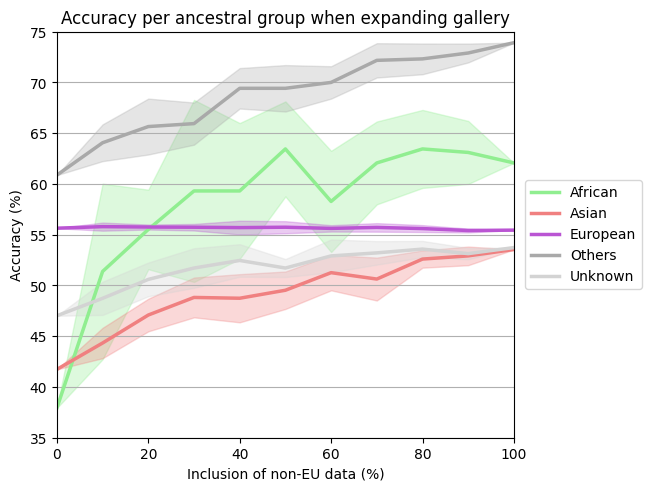

In [7]:
fig, ax = plt.subplots(layout='constrained')

plt.ylim(35,75)
plt.xlim(0,10)

x = np.arange(len(performances[1:,0,0]))
x_labels = np.linspace(0, 100, num=len(performances[1:,0,0]), dtype=int)  # 11 labels ranging from 0 to 100
ticks_to_display = [0, 2, 4, 6, 8, 10]
plt.xticks(ticks_to_display, x_labels[ticks_to_display])

plt.plot(performances[1:,0,0]*100, linewidth=2.5, c='lightgreen', label="African")
plt.fill_between(x, performances_upper[1:,0,0]*100, performances_lower[1:,0,0]*100, color='lightgreen', alpha=0.3)
plt.plot(performances[1:,1,0]*100, linewidth=2.5, c='lightcoral', label="Asian")
plt.fill_between(x, performances_upper[1:,1,0]*100, performances_lower[1:,1,0]*100, color='lightcoral', alpha=0.3)
plt.plot(performances[1:,2,0]*100, linewidth=2.5, c='mediumorchid', label="European")
plt.fill_between(x, performances_upper[1:,2,0]*100, performances_lower[1:,2,0]*100, color='mediumorchid', alpha=0.3)
plt.plot(performances[1:,3,0]*100, linewidth=2.5, c='darkgray', label="Others")
plt.fill_between(x, performances_upper[1:,3,0]*100, performances_lower[1:,3,0]*100, color='darkgray', alpha=0.3)
plt.plot(performances[1:,4,0]*100, linewidth=2.5, c='lightgray', label="Unknown")
plt.fill_between(x, performances_upper[1:,4,0]*100, performances_lower[1:,4,0]*100, color='lightgray', alpha=0.3)
handles, labels = plt.gca().get_legend_handles_labels()

# plt.xlabel("Proportion of available diverse ancestral data (%)")
plt.xlabel("Inclusion of non-EU data (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per ancestral group when expanding gallery")

extra_lines = [
#     plt.Line2D([], [], linestyle='-', label='Top-1', color='black', linewidth=2.5),
#     plt.Line2D([], [], linestyle='--', label='Top-5', color='black', linewidth=1.5)
               ]
labels.append(['Top-1', 'Top-5'])
plt.legend(handles=handles+extra_lines, loc='center left', bbox_to_anchor=(1.01, 0.5))

plt.grid(True, which='major', axis='y', linestyle='-')

plt.savefig('accuracy_eth_proportion_sort.svg', dpi=300)
plt.show()